In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import scipy.stats as sts
import astropy.units as u
from astropy.constants import G,M_sun,kpc
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

plt.rcParams["axes.linewidth"]  = 2
plt.rcParams["xtick.major.size"]  = 8
plt.rcParams["xtick.minor.size"]  = 3
plt.rcParams["ytick.major.size"]  = 8
plt.rcParams["ytick.minor.size"]  = 3
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams.update({'font.size': 24})
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams["mathtext.default"] = 'rm'
plt.rcParams["mathtext.fontset"] = 'cm'

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
gls = sim()
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:24: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:25: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:26: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_gas', mconv + np.log10(self.hst.GroupMassType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:27: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [3]:
lll,llh,llg,llf,llhf = sim.gal_select(gls)

N_lll = len(lll)
print(N_lll)
llm = [len(x) for x in llg]

N_llf = len(llf)
print(N_llf)

9364
638
6737


In [5]:
host_bins = [np.where(gls.hst.group_m200[llh]<11.2)[0],np.where((gls.hst.group_m200[llh]>=11.2)&(gls.hst.group_m200[llh]<12))[0],np.where(gls.hst.group_m200[llh]>=12)[0]]
bin_cols = ['dodgerblue','tomato','goldenrod']
qf_labels = [r'$\mathcal{M}_{200}< 10^{11} M_\odot$',r'$10^{11} M_\odot < \mathcal{M}_{200}< 10^{12} M_\odot$',r'$\mathcal{M}_{200}> 10^{12} M_\odot$']


In [6]:
def behroozi(mhalo): 
    x = mhalo - 12.060
    return  12.06-1.459 - np.log10(np.power(10,-1.972*x) + np.power(10,-0.488*x))-0.958*np.exp(-0.5*np.square(x/0.391))

mhalo_bin = np.linspace(10,12,50)

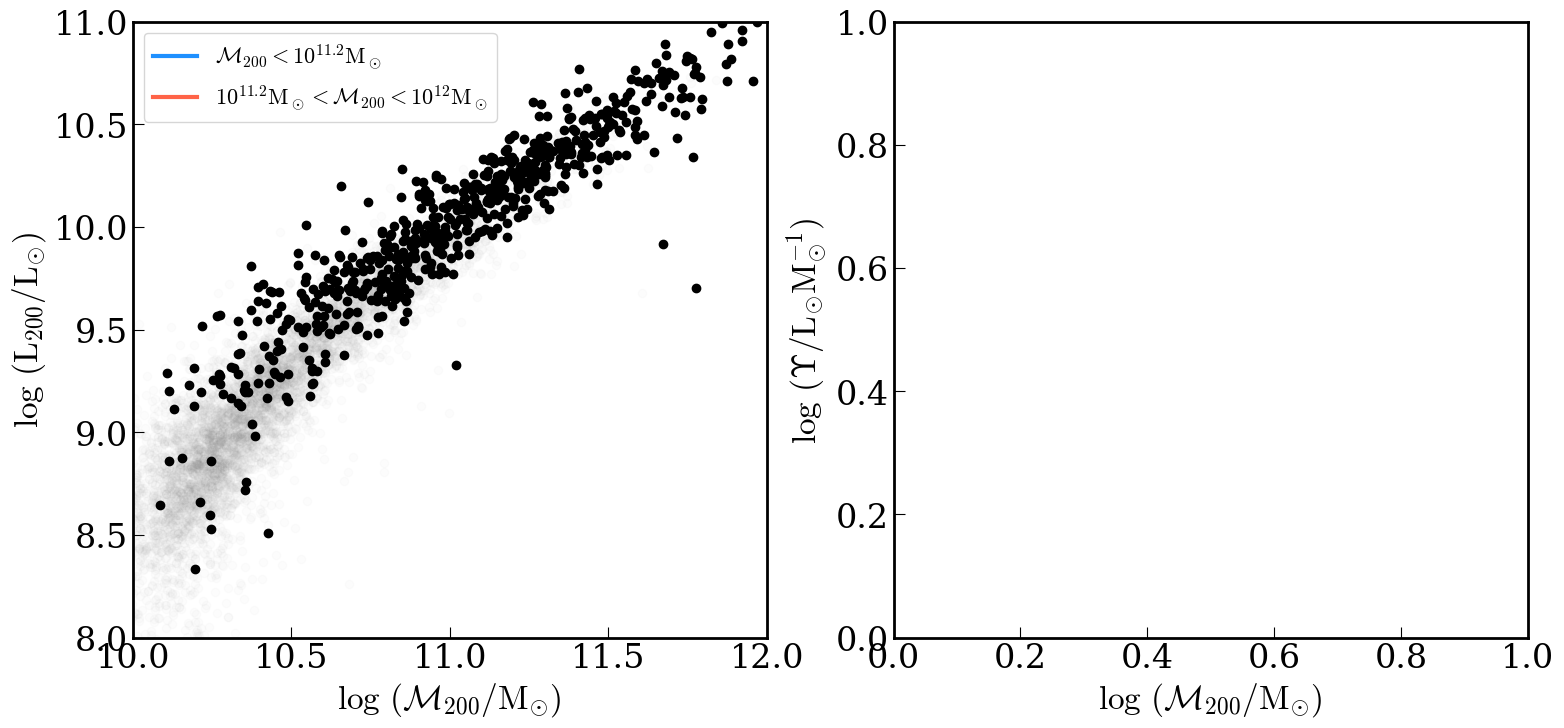

In [13]:
host_all,Lsat_all,MtoL_all = [],[],[]
wt_all = []
mbin = np.linspace(10,12,21)

fig,ax=plt.subplots(1,2,figsize=(18,8))

ax[0].plot(gls.hst.group_m200[llhf],gls.hst.group_gas[llhf],ls='none',marker='o',c='gray',alpha=0.02)
ax[0].plot(gls.hst.group_m200[llh],gls.hst.group_gas[llh],ls='none',marker='o',c='black')

ax[0].set_xlim((10,12))
ax[0].set_ylim((8,11))

'''
for k in range(2):  
    m200,lsat,mtol,nsat = [],[],[],[]
    for i in host_bins[k]:
            r = np.sqrt(np.square(gls.sub.SubhaloPos[llg[i],0]-gls.hst.GroupPos[llh[i],0])+np.square(gls.sub.SubhaloPos[llg[i],1]-gls.hst.GroupPos[llh[i],1])+np.square(gls.sub.SubhaloPos[llg[i],2]-gls.hst.GroupPos[llh[i],2]))
            close = llg[i][np.where(r<gls.hst.Group_R_Crit200[llh[i]])[0]]

            lsat.append(lsum)
            m200.append(gls.hst.group_m200[llh[i]])
            nsat.append(llm[i]+1)
            mtol.append(gls.hst.group_m200[llh[i]] - lsum)
                
    host_all.extend(m200)
    Lsat_all.extend(lsat)
    MtoL_all.extend(mtol)
                
    ax[0].plot(m200,lsat,ls='none',marker='o',c=bin_cols[k],alpha=0.5)
    ax[1].plot(m200,mtol,ls='none',marker='o',c=bin_cols[k],alpha=0.5)
    ax[k].set_xlim((9,12))
    
    
p0,p1 = sopt.curve_fit(linear,host_all,Lsat_all)
print(p0,p1)
ax[0].plot(mbin,linear(mbin,*p0),lw=3,color='black')
ax[1].plot(mbin,mbin-linear(mbin,*p0),lw=3,color='black')


p0,p1 = sopt.curve_fit(tully_fit,host_all,Lsat_all)
print(p0,p1)
ax[1].plot(mbin,tully_fit(mbin,*p0),lw=3,color='black')


bin_lsat, bin_edg, bin_n = sts.binned_statistic(host_all,Lsat_all, statistic='median', bins=np.linspace(10.5,12.5,6))
bin_lstd, bin_edg, bin_n = sts.binned_statistic(host_all,Lsat_all, statistic='std', bins=np.linspace(10.5,12.5,6))

bin_mtol, bin_edg, bin_n = sts.binned_statistic(host_all,MtoL_all, statistic='median', bins=np.linspace(10.5,12.5,6))
bin_mlst, bin_edg, bin_n = sts.binned_statistic(host_all,MtoL_all, statistic='std', bins=np.linspace(10.5,12.5,6))

bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
ax[0].errorbar(bin_edg[:-1],bin_lsat,yerr=bin_lstd,marker='o',ls='none',color='black')
ax[1].errorbar(bin_edg[:-1],bin_mtol,yerr=bin_mlst,marker='o',ls='none',color='black')
'''
#ax.plot(np.linspace(10,12,11),1.1)
custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1])]
leg=Legend(ax[0],custom_lines,[r'$\mathcal{M}_{200}< 10^{11.2} M_\odot$',r'$10^{11.2} M_\odot < \mathcal{M}_{200}< 10^{12} M_\odot$'],loc='best',fontsize=16,framealpha=0.8,frameon=True)
ax[0].add_artist(leg)

ax[0].set_ylabel('$log\ (L_{200}/L_{\odot})$',fontsize=24)
ax[0].set_xlabel('$log\ (\mathcal{M}_{200}/M_{\odot})$',fontsize=24)

ax[1].set_ylabel(r'$log\ (\Upsilon /L_{\odot} M_{\odot}^{-1})$',fontsize=24)
ax[1].set_xlabel(r'$log\ (\mathcal{M}_{200}/M_{\odot})$',fontsize=24)
#ax.set_xlabel(r'$M_r - 5log\ h$',fontsize=26)
#ax.set_ylabel(r'$log\ \Phi_{sat}(M_r)$',fontsize=26)
plt.savefig('subhalo_LsatMtoL.pdf',bbox_inches='tight')

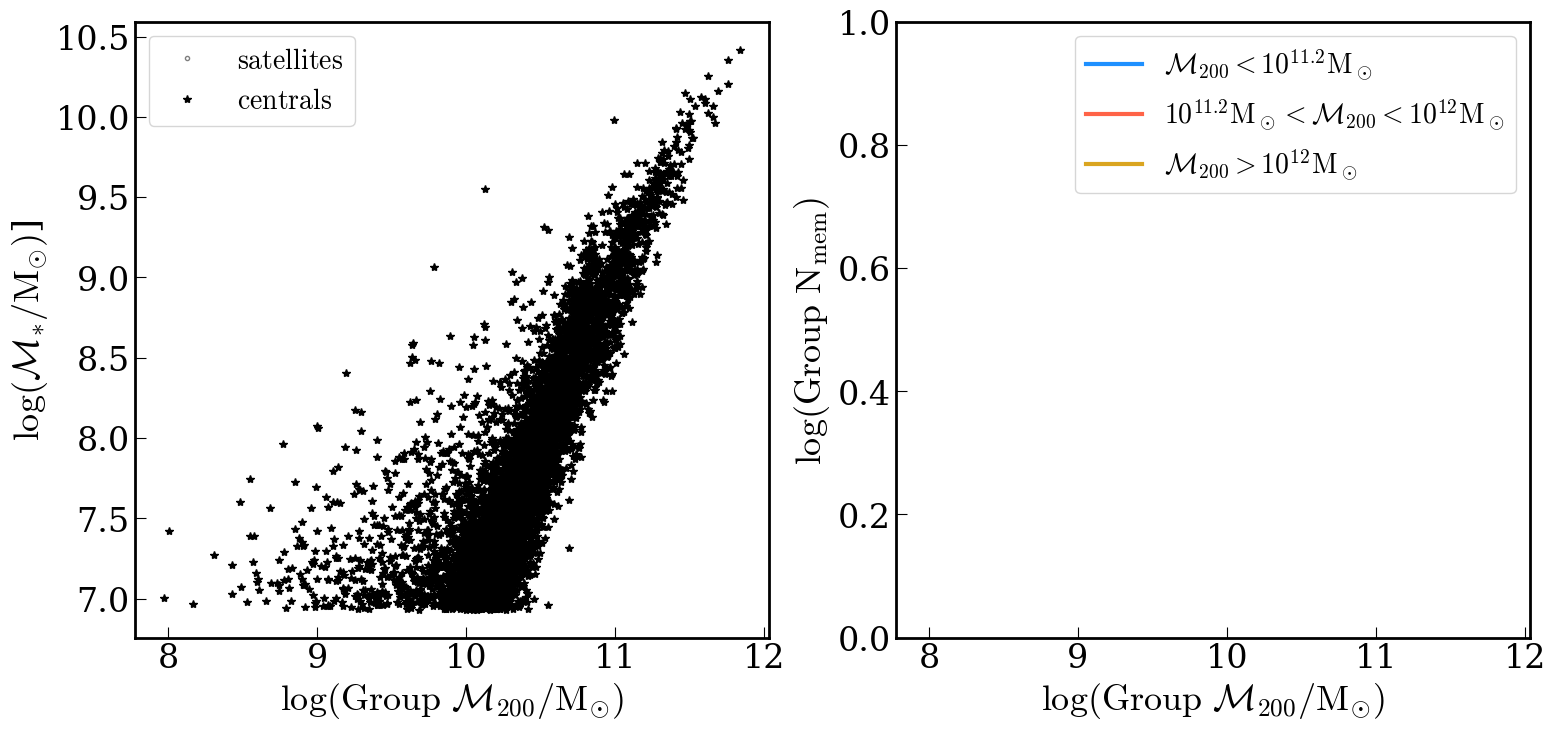

In [6]:
fig,ax=plt.subplots(1,2,figsize=(18,8),sharex=True)

#for k in range(3):
#    for i in host_bins[k]: 
ax[0].plot(gls.hst.group_m200[llhf],gls.sub.mst[llf],'*',color='black')

#ax[1].plot(gls.hst.group_m200[llhf,np.log10(llm[i]+1),'.',color=bin_cols[k])

'''for j in range(2):
    ax[j].axhline(8,ls=':',lw=3,color='black')
    ax[j].axhline(10,ls=':',lw=3,color='black')
#ax.set_xscale('log')
#ax.set_yscale('log')'''
ax[0].set_xlabel(r'$log(Group\ \mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax[1].set_xlabel(r'$log(Group\ \mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax[1].set_ylabel(r'$log(Group\ N_{mem})$',fontsize=26)
ax[0].set_ylabel(r'$log(\mathcal{M}_{\ast}/M_{\odot})$]',fontsize=26)

'''ax[0].axhline(9.0,ls='--',color='black')
ax[0].axhline(10.0,ls='--',color='black')
ax[0].axvline(11.25,ls='-.',color='black')
ax[0].axvline(12.0,ls='-.',color='black')'''

custom_lines = [Line2D([0], [0],ls='none',marker='.',mfc='none', color='black',alpha=0.5),Line2D([0], [0],ls='none',marker='*',color='black')]
leg=Legend(ax[0],custom_lines,[r'$satellites$',r'$centrals$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1]),Line2D([0], [0],lw=3, color=bin_cols[2])]
leg=Legend(ax[1],custom_lines,[r'$\mathcal{M}_{200}< 10^{11.2} M_\odot$',r'$10^{11.2} M_\odot < \mathcal{M}_{200}< 10^{12} M_\odot$',r'$\mathcal{M}_{200}> 10^{12} M_\odot$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[1].add_artist(leg)

ax[0].set_rasterized(True)
ax[1].set_rasterized(True)
plt.subplots_adjust(wspace=0.2)
plt.savefig('group_shmr_count.pdf',bbox_inches='tight')

In [6]:
print(len(host_bins[0]),len(host_bins[1]),len(host_bins[2]))

377 331 22


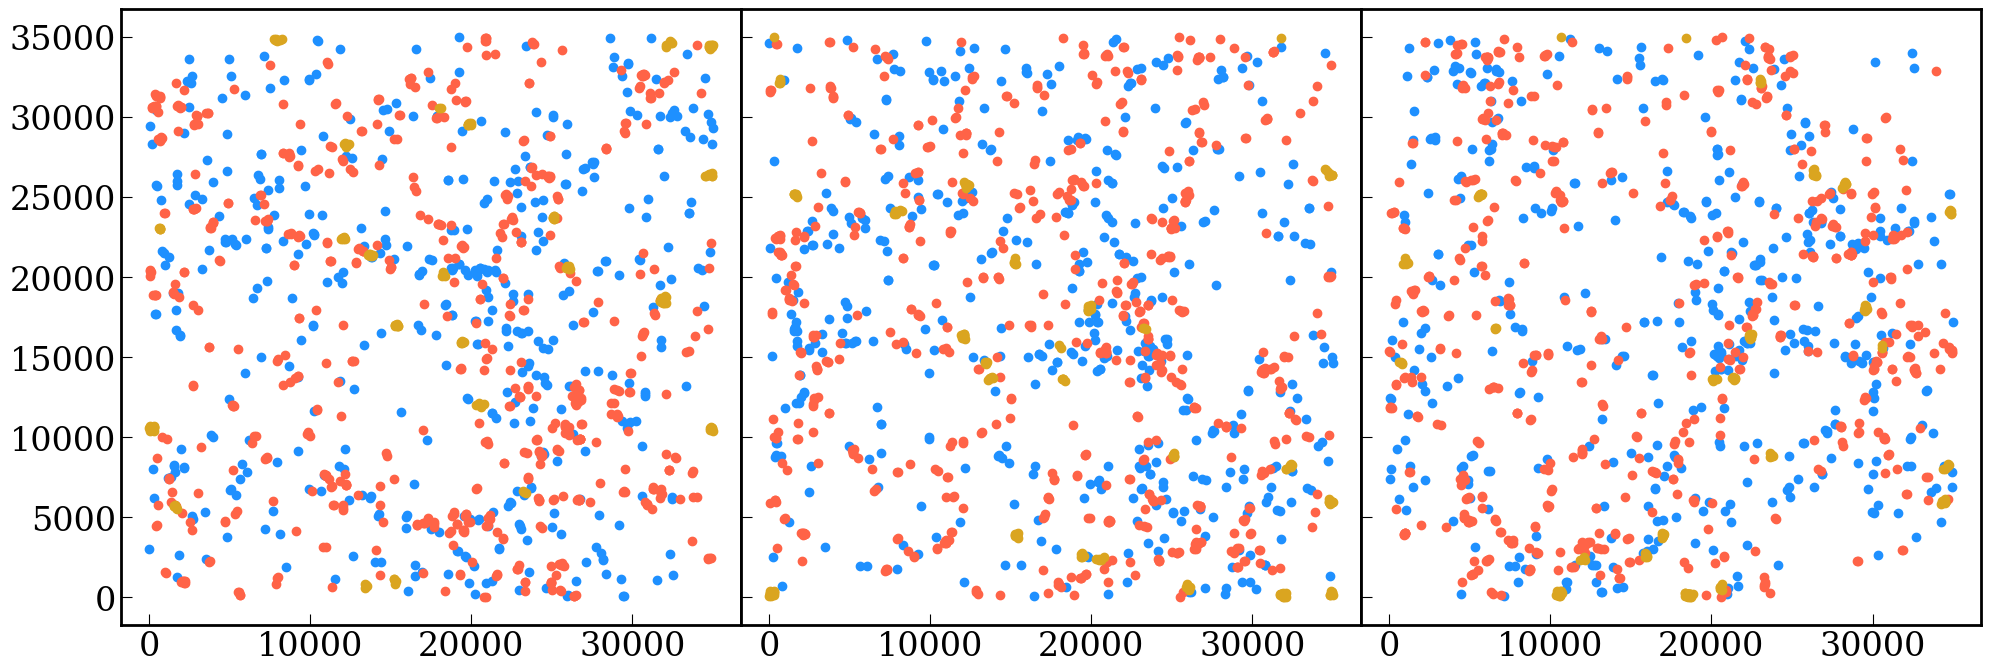

In [7]:
fig,ax=plt.subplots(1,3,figsize=(24,8),sharey=True)

for k in range(3):
    for i in host_bins[k]: 
        ax[0].scatter(gls.sub.SubhaloPos[llg[i],0],gls.sub.SubhaloPos[llg[i],1],color=bin_cols[k])
        ax[1].scatter(gls.sub.SubhaloPos[llg[i],0],gls.sub.SubhaloPos[llg[i],2],color=bin_cols[k])
        ax[2].scatter(gls.sub.SubhaloPos[llg[i],1],gls.sub.SubhaloPos[llg[i],2],color=bin_cols[k])

plt.subplots_adjust(wspace=0.0)

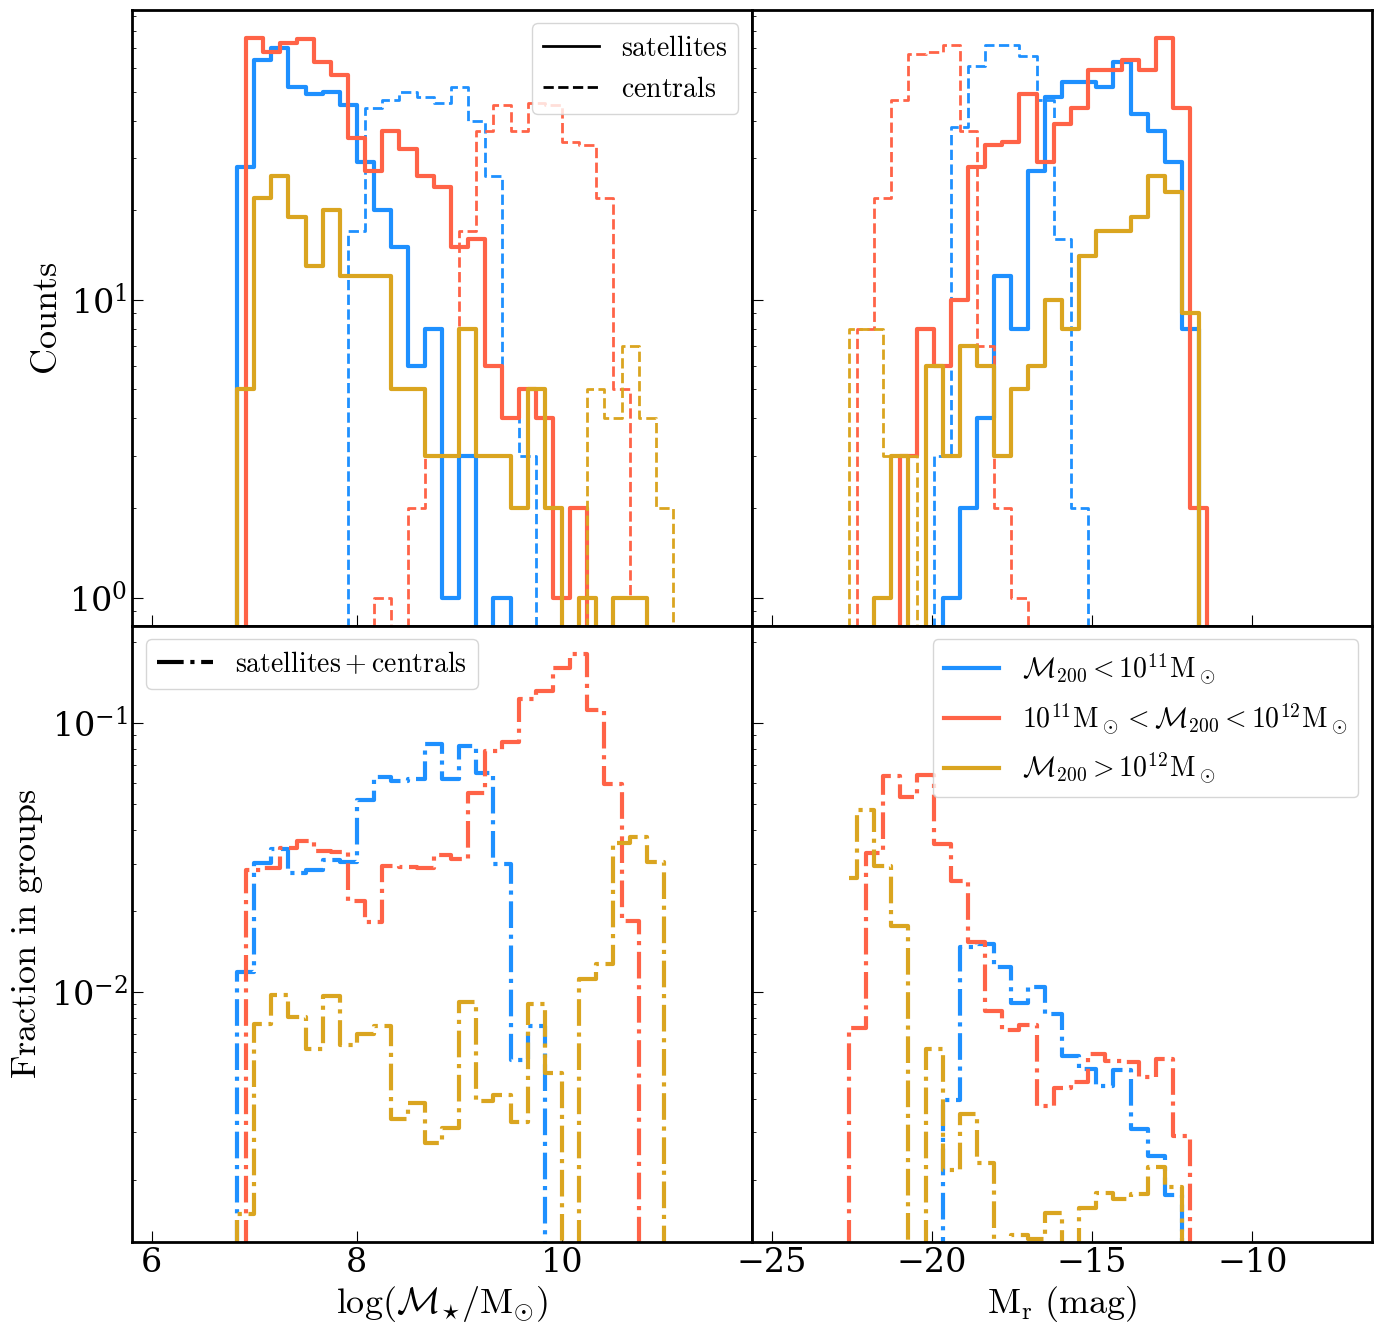

In [8]:
fig,ax=plt.subplots(2,2,figsize=(16,16),sharex='col',sharey='row')
mstar_bins = np.linspace(6.0,11.0,31)
absm_bins = np.linspace(-25,-9,31)

bin_all_smf, bin_edg = np.histogram(gls.sub.mst,bins=mstar_bins)
bin_all_lmf, bin_edg = np.histogram(gls.sub.SubhaloStellarPhotometrics,bins=absm_bins)


for k in range(3):
    grp_smf,grp_lmf = [],[]
    cen_smf,cen_lmf = [],[]
    for i in host_bins[k]: 
        grp_smf.extend(gls.sub.mst[llg[i]])
        grp_lmf.extend(gls.sub.SubhaloStellarPhotometrics[llg[i],5])
        
        cen_smf.append(gls.sub.mst[lll[i]])
        cen_lmf.append(gls.sub.SubhaloStellarPhotometrics[lll[i],5])
        
    bin_sat, bin_edg = np.histogram(grp_smf,bins=mstar_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[0,0].step(bin_edg[:-1],bin_sat,lw=3,color=bin_cols[k],where='mid')
    
    bin_sat, bin_edg = np.histogram(grp_lmf,bins=absm_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[0,1].step(bin_edg[:-1],bin_sat,lw=3,color=bin_cols[k],where='mid')
    
    bin_sat, bin_edg = np.histogram(cen_smf,bins=mstar_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[0,0].step(bin_edg[:-1],bin_sat,color=bin_cols[k],ls='--',lw=2,where='mid')
    
    bin_sat, bin_edg = np.histogram(cen_lmf,bins=absm_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[0,1].step(bin_edg[:-1],bin_sat,color=bin_cols[k],ls='--',lw=2,where='mid')
    
    grp_smf.extend(cen_smf)    
    bin_sat, bin_edg = np.histogram(grp_smf,bins=mstar_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[1,0].step(bin_edg[:-1],bin_sat/bin_all_smf,lw=3,ls='-.',color=bin_cols[k],where='mid')
    
    grp_lmf.extend(cen_lmf)
    bin_sat, bin_edg = np.histogram(grp_lmf,bins=absm_bins)
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    ax[1,1].step(bin_edg[:-1],bin_sat/bin_all_lmf,lw=3,ls='-.',color=bin_cols[k],where='mid')

for i in range(2):
    for j in range(2):
        ax[i,j].set_yscale('log')
        ax[i,j].set_yscale('log')

ax[1,0].set_xlabel(r'$log(\mathcal{M}_{\star}/M_{\odot})$',fontsize=26)
ax[0,0].set_ylabel(r'$Counts$',fontsize=26)
ax[1,0].set_ylabel(r'$Fraction\ in\ groups$',fontsize=26)
ax[1,1].set_xlabel(r'$M_r\ (mag)$',fontsize=26)

custom_lines = [Line2D([0], [0],lw=2, color='black'), Line2D([0], [0],lw=2,ls='--',color='black')]
leg=Legend(ax[0,0],custom_lines,[r'$satellites$',r'$centrals$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[0,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3,ls='-.', color='black')]
leg=Legend(ax[1,0],custom_lines,[r'$satellites+centrals$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[1,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3, color=bin_cols[0]), Line2D([0], [0],lw=3, color=bin_cols[1]),Line2D([0], [0],lw=3, color=bin_cols[2])]
leg=Legend(ax[1,1],custom_lines,[r'$\mathcal{M}_{200}< 10^{11} M_\odot$',r'$10^{11} M_\odot < \mathcal{M}_{200}< 10^{12} M_\odot$',r'$\mathcal{M}_{200}> 10^{12} M_\odot$'],loc='best',fontsize=20,framealpha=0.8,frameon=True)
ax[1,1].add_artist(leg)
        
plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('group_relative_distrib.pdf',bbox_inches='tight')

In [77]:
print(np.shape(sub_halos['SubhaloVel'][llg[i],:]-host_halos['GroupVel'][llh[i],:]))
print(np.shape(np.transpose(sub_halos['SubhaloPos'][llg[i],:]-host_halos['GroupPos'][llh[i],:])))

(421, 3)
(3, 421)


In [8]:

print(1e-5/np.sqrt((G*M_sun/kpc)))

4.821913947130927e-06 s / m


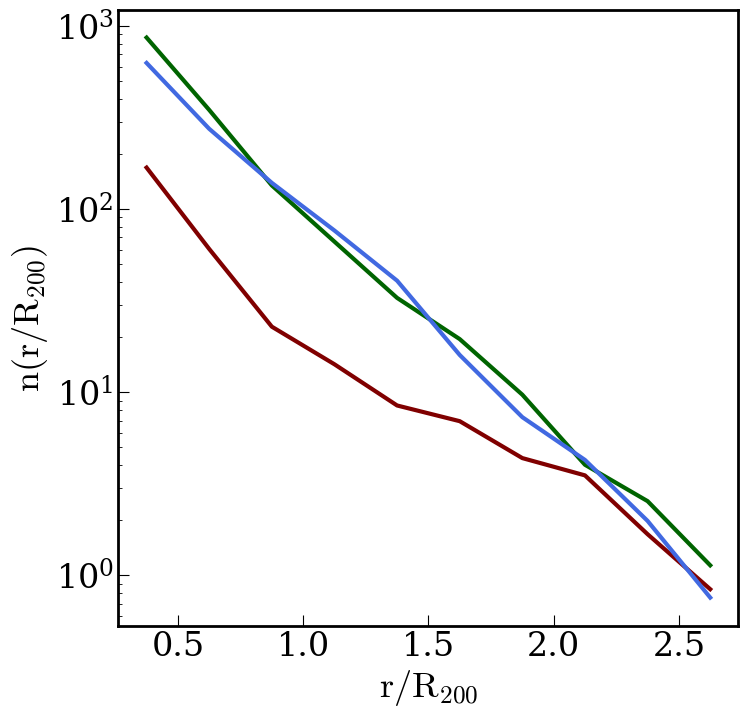

In [16]:
mstar_bins = np.linspace(6.0,9.0,21)
r_bins = np.arange(0.25,3,0.25)
bin_cols = ['maroon','darkgreen','royalblue']

fig,ax=plt.subplots(figsize=(8,8))

ax.set_xlabel(r'$r/R_{200}$',fontsize=26)
ax.set_ylabel(r'$n(r/R_{200})$',fontsize=26)

host_bins = [np.where(group_m200[llh]<11)[0],np.where((group_m200[llh]>=11)&(group_m200[llh]<12))[0],np.where(group_m200[llh]>=12)[0]]

for k in range(3):
    grp_rad = []
    for i in host_bins[k]: 
            r = np.sqrt(np.square(sub_halos['SubhaloPos'][llg[i],0]-sub_halos['SubhaloPos'][lll[i],0])+np.square(sub_halos['SubhaloPos'][llg[i],1]-sub_halos['SubhaloPos'][lll[i],1])+np.square(sub_halos['SubhaloPos'][llg[i],2]-sub_halos['SubhaloPos'][lll[i],2]))
            grp_rad.extend(r/host_halos['Group_R_Crit200'][llh[i]])
        
    bin_host, bin_edg = np.histogram(grp_rad,bins=r_bins)
    bin_mid=bin_edg+0.5*(bin_edg[1]-bin_edg[0])
    scal = 0.2387324146/(np.power(bin_mid[1:],3) - np.power(bin_mid[:-1],3))
    ax.plot(bin_mid[:-1],scal*bin_host,lw=3,color=bin_cols[k])
        
ax.set_yscale('log')
#ax[0].set_ylim(bottom=1e-2)


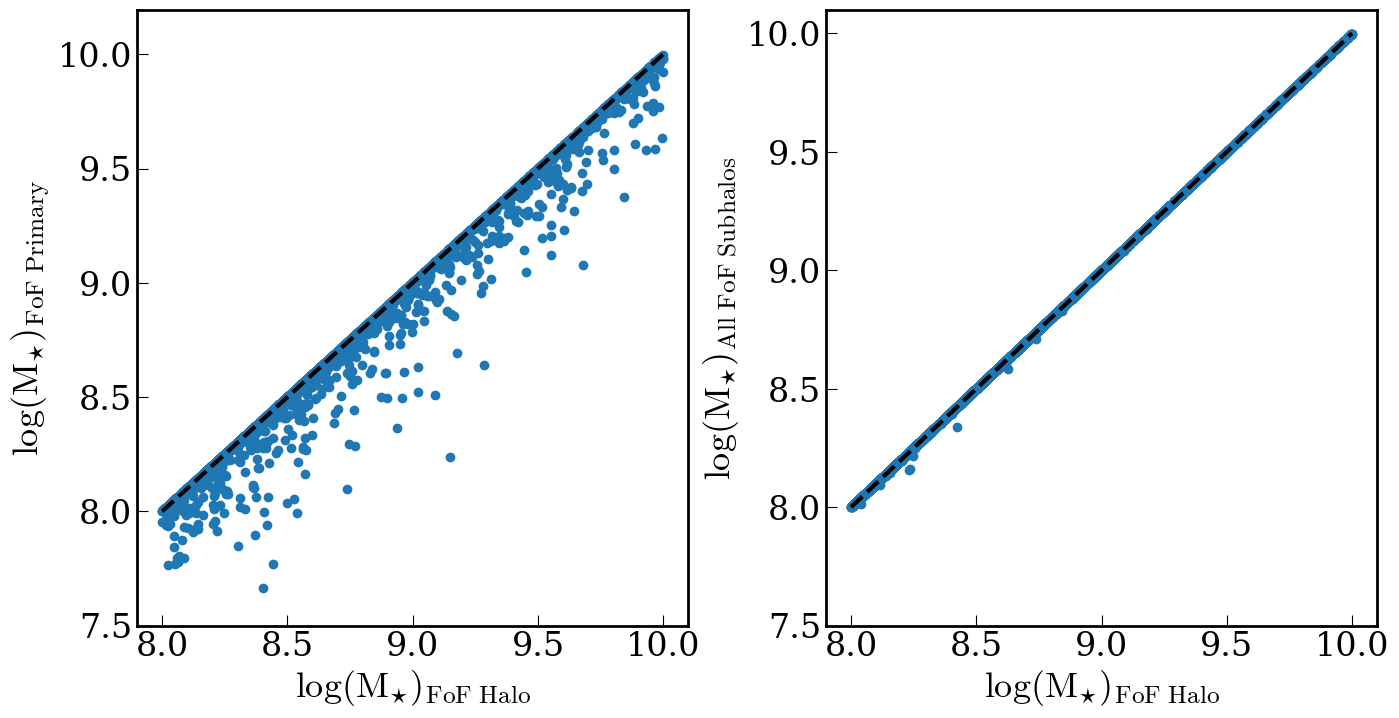

In [37]:
mst_arr = np.linspace(8,10,10)

fig,ax=plt.subplots(1,2,figsize=(16,8))

ax[0].plot(host_stellar[lmc_like],prim_mass,ls='none',marker='o')
ax[0].plot(mst_arr,mst_arr,ls='--',lw=3,color='black')
ax[0].set_ylim(bottom=7.5)

ax[0].set_xlabel(r'$log(M_{\star})_{FoF\ Halo}$',fontsize=26)
ax[0].set_ylabel(r'$log(M_{\star})_{FoF\ Primary}$',fontsize=26)

ax[1].plot(mst_arr,mst_arr,ls='--',lw=3,color='black')
ax[1].plot(host_stellar[lmc_like],total_mass,ls='none',marker='o')
ax[1].plot(mst_arr,mst_arr,ls='--',lw=3,color='black')
ax[1].set_ylim(bottom=7.5)

ax[1].set_xlabel(r'$log(M_{\star})_{FoF\ Halo}$',fontsize=26)
ax[1].set_ylabel(r'$log(M_{\star})_{All\ FoF\ Subhalos}$',fontsize=26)

plt.subplots_adjust(hspace=0.0,wspace=0.25)